<a href="https://colab.research.google.com/github/mserhat1/NMA_Project/blob/main/testing_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/mserhat1/NMA_Project.git
import sys
sys.path.append('/content/NMA_Project')

Cloning into 'NMA_Project'...
remote: Enumerating objects: 355, done.
remote: Counting objects: 100% (160/160), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 355 (delta 94), reused 18 (delta 5), pack-reused 195 (from 1)
Receiving objects: 100% (355/355), 14.13 MiB | 18.47 MiB/s, done.
Resolving deltas: 100% (196/196), done.


In [ ]:
%cd NMA_Project
!pip install -r requirements.txt

In [3]:
from functions.data import get_datafile

# sbj 6 has visual cortex electrodes

sbj = 10
session = 3

nwbfile = get_datafile(sbj=sbj, session=session)

/usr/local/lib/python3.11/dist-packages/hdmf/spec/namespace.py:583: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
ndx-events - cached version: 0.2.0, loaded version: 0.2.1
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Extract spatial data

In [4]:
from functions.data import extract_spatial_data

spatial_data = extract_spatial_data(nwbfile)

Extract neural data

In [5]:
from functions.data import extract_neural_data

# specify parameters
channel = 'all'
#train_window = (0, 43200)
#test_window = (43200, 86400)

ecog_data = extract_neural_data(nwbfile, channel=channel, time_window=(55000, 56500))

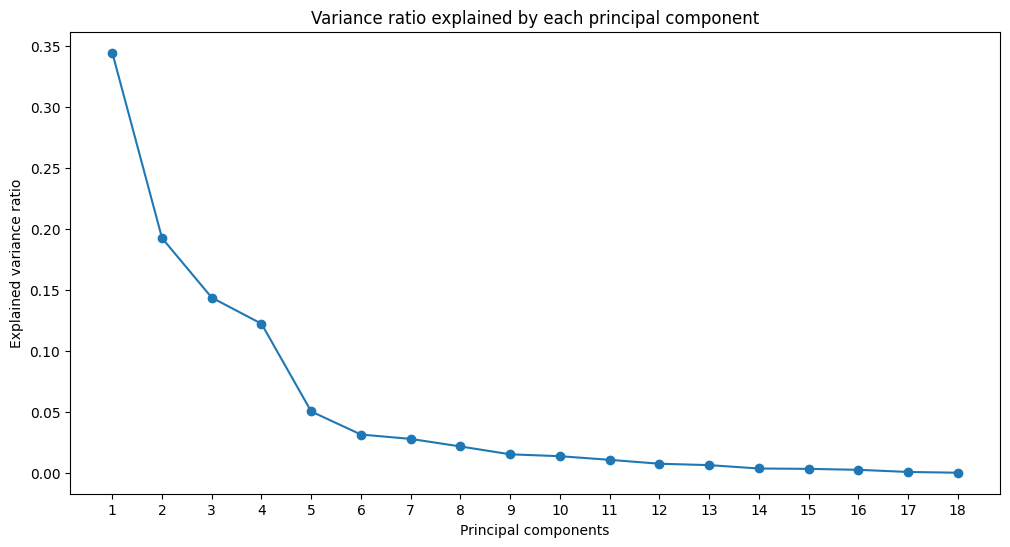

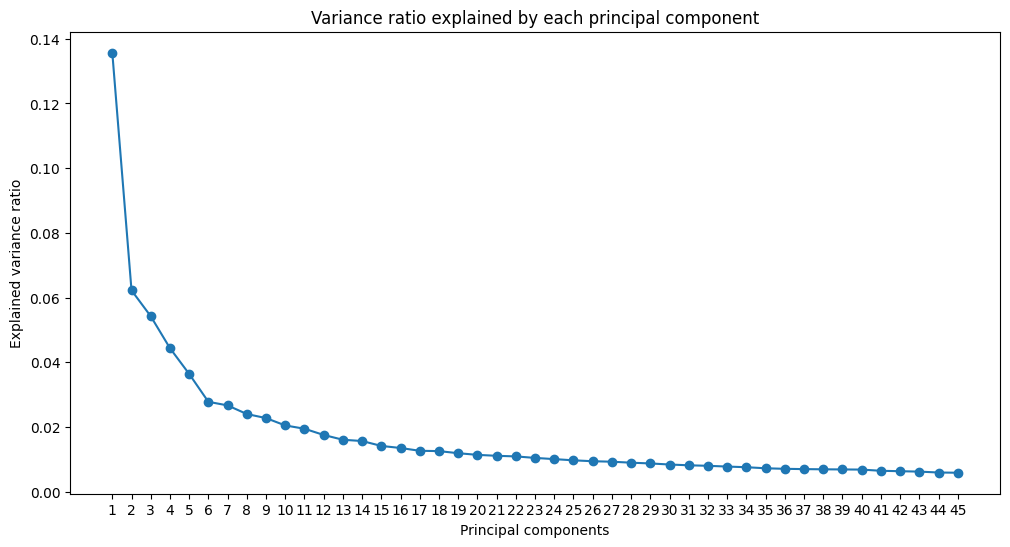

In [9]:
from functions.analysis import keypoints_pca, ecog_pca

spatial_pca = keypoints_pca(spatial_data, interp_reference=ecog_data['signal'], time_window=(55000, 56500), plot=True)
neural_pca = ecog_pca(ecog_data, time_window=(55000, 56500), n_components=0.80, plot=True)

In [12]:
# Seems like 4 PC's is a good choice in this case.
chosen_pcs = 4

kp_data = spatial_pca['kp_data']
pcs = spatial_pca['components'] # (n_components, n_features)
top_pcs = pcs[:chosen_pcs, :]

print(top_pcs.shape, kp_data.shape)
projected_spatial = kp_data @ top_pcs.T

print(projected_spatial.shape) # (n_samples, n_components)

(4, 18) (750000, 18)
(750000, 4)


In [17]:
chosen_pcs = 12
neural_data = neural_pca['kp_data']
pcs = neural_pca['components'] # (n_components, n_features)
top_pcs = pcs[:chosen_pcs, :]

print(top_pcs.shape, neural_data.shape)
projected_neural = neural_data @ top_pcs.T

print(projected_neural.shape) # (n_samples, n_components)

(12, 126) (750000, 126)
(750000, 12)


In [18]:
from functions.model import RRR

A, C = RRR(projected_spatial, projected_neural)

In [19]:
print(A.shape, C.shape)

(4, 4) (12, 4)


TRAINING AND TEST

In [ ]:
from functions.data import extract_spatial_data
from functions.data import extract_neural_data
from functions.analysis import keypoints_pca, ecog_pca

train_window = (0, 43200)
test_window = (43200, 86400)

spatial_data = extract_spatial_data(nwbfile)
ecog_train = extract_neural_data(nwbfile, channel=channel, time_window=train_window)
ecog_test = extract_neural_data(nwbfile, channel=channel, time_window=test_window)

spatial_pca_train = keypoints_pca(spatial_data, interp_reference=ecog_data['signal'], time_window=train_window, plot=False)
neural_pca_train = ecog_pca(ecog_data, time_window=train_window, n_components=0.80, plot=False)

spatial_pca_test = keypoints_pca(spatial_data, interp_reference=ecog_data['signal'], time_window=test_window, plot=False)
neural_pca_test = ecog_pca(ecog_data, time_window=test_window, n_components=0.80, plot=False)



